### Install packages

In [79]:
import simpy 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
np.random.seed(42) # set seed to ensure reproducible results

### Queueing Model Description

- **Arrivals:** Patients arrive according to a Poisson process with rate $\lambda(t)$, which varies over time to capture peak demand. During the peak period (10:00–14:00), the arrival rate is increased by a multiplier:

$$
\lambda(t) =
\begin{cases}
\lambda \times m, & \text{if } 2 \leq t < 6 \\
\lambda, & \text{otherwise}
\end{cases}
$$

Interarrival times are therefore exponentially distributed with mean $1/\lambda(t)$.

- **Service:** Consultation times follow an exponential distribution with rate $\mu$, so the average service time is $1/\mu$.

- **System structure:** The clinic is modelled as an $M(t)/M/c$ queue with $c$ clinicians and a single shared queue.

- **Performance metrics:**
  - **Waiting time:** time from arrival to start of service  
  - **Time in system:** total time from arrival to departure  
  - **Number in system:** number of patients waiting or being treated  

- **Time-average number in system:**  
This is computed as the area under the curve $L(t)$ divided by total time:

$$
\bar{L} = \frac{1}{T} \int_0^T L(t)\,dt
$$

This provides an estimate of $E[L]$, the average number of patients in the system, which is related to the average time in system through Little’s Law:
$$
E[L] = \lambda E[W].
$$

In [80]:
class QueueSimulation:

    def __init__(self, lambda_rate, mu_rate, duration, num_servers, multiplier):
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.duration = duration # hours to run the simulation
        self.num_servers = num_servers
        self.multiplier = multiplier

    def current_lambda(self, t):
        if 2 <= t < 6: # peak demand period (assuming opens at 8am, t=2 is 10am, t=6 is 2pm)
            return self.lambda_rate * self.multiplier # multiply by number in range 2-4 as specified 
        return self.lambda_rate

    def interarrival(self, t):
        return np.random.exponential(1 / self.current_lambda(t))

    def service_time(self):
        return np.random.exponential(1 / self.mu_rate)

    def system_size(self):
        return len(self.servers.queue) + len(self.servers.users)

    def arrival_process(self, env):
        while True:
            yield env.timeout(self.interarrival(env.now))
            env.process(self.patient(env))

    def patient(self, env):
        t_arrival = env.now
        self.system_sizes.append((t_arrival, self.system_size()))

        with self.servers.request() as req:
            yield req

            t_service = env.now
            wait_time = t_service - t_arrival

            service_duration = self.service_time()
            yield env.timeout(service_duration)

            t_depart = env.now
            time_in_system = t_depart - t_arrival

            self.system_sizes.append((t_depart, self.system_size() - 1))

            self.wait_times.append(wait_time)
            self.time_in_system.append(time_in_system)
            self.service_times.append(service_duration)

    def run(self):
        self.wait_times = []
        self.time_in_system = []
        self.service_times = []
        self.system_sizes = [(0, 0)]

        env = simpy.Environment()
        self.servers = simpy.Resource(env, capacity=self.num_servers)

        env.process(self.arrival_process(env))
        env.run(until=self.duration)

        self.system_sizes.append((self.duration, self.system_size()))

        avg_service = np.mean(self.service_times)
        avg_wait = np.mean(self.wait_times)
        avg_time = np.mean(self.time_in_system)
        
        # average number of patients in system at any given time using area under step function
        auc, last_t, last_l = 0, 0, 0
        for t, l in self.system_sizes:
            auc += (t - last_t) * last_l
            last_t, last_l = t, l

        avg_L = auc / last_t

        return avg_service, avg_wait, avg_time, avg_L

### Simulation of Daily Operation

To capture day-to-day variability in demand, we simulate multiple independent runs of the system, each representing a single day of operation. For each run, the baseline arrival rate and peak multiplier are randomly sampled within the specified ranges.

Performance metrics are aggregated across runs, including:
- average service time
- average waiting time in queue
- average time in system
- 90th percentile of time in system
- average number of patients in the system
- maximum system size during the day
- end-of-day backlog
- proportion of patients waiting more than 1 hour

This allows us to estimate typical system performance under variability in demand, rather than relying on a single realisation.

In [ ]:
def run_random_day():
    lambda_rate = np.random.uniform(8, 16)
    multiplier = np.random.uniform(2, 4)

    sim = QueueSimulation(
        lambda_rate=lambda_rate,
        mu_rate=2,
        duration=10,
        num_servers=6,
        multiplier=multiplier
    )

    return sim, sim.run()

runs = 100

services_all = []
wait_times_all = []
time_in_system_all = []
system_means = []
max_system = []
backlogs = []

for i in range(runs):
    sim, (avg_service, avg_wait, avg_time, avg_L) = run_random_day()

    services_all.append(avg_service)
    system_means.append(avg_L)

    wait_times_all.extend(sim.wait_times)
    time_in_system_all.extend(sim.time_in_system)

    # extract system sizes over time
    sizes = [l for t, l in sim.system_sizes]
    max_system.append(max(sizes))
    backlogs.append(sizes[-1])

wait_times_all = np.array(wait_times_all)
time_in_system_all = np.array(time_in_system_all)

print("Baseline results:")
print("Mean service time:", np.mean(services_all))
print("Mean queue wait:", np.mean(wait_times_all))
print("Mean time in system:", np.mean(time_in_system_all))
print("90th percentile time in system:", np.percentile(time_in_system_all, 90))
print("Mean number in system:", np.mean(system_means))
print("Average max system size:", np.mean(max_system))
print("Average backlog:", np.mean(backlogs))
print("Proportion >1hr:", np.mean(time_in_system_all > 1))

Baseline results:
Mean service time: 0.47293819028986483
Mean queue wait: 1.9412779519025163
Mean time in system: 2.4104220652083748
90th percentile time in system: 4.835567193914588
Mean number in system: 63.92973060188815
Average max system size: 110.94
Average backlog: 103.77
Proportion >1hr: 0.7322491779969785


### Expected Waiting Time (Erlang C Formula)

To understand how waiting times depend on demand, we use the analytical expression for the expected waiting time in an $M/M/c$ queue.

Let $\lambda$ be the arrival rate, $\mu$ the service rate, and $c$ the number of servers. Define the utilisation:
$$
\rho = \frac{\lambda}{c\mu}.
$$

The probability that an arriving patient has to wait (Erlang C formula) is:
$$
P(W > 0) = \frac{\left(\frac{\lambda}{\mu}\right)^c}{c! (1 - \rho)} P_0,
$$

where
$$
P_0 = \left[ \sum_{n=0}^{c-1} \frac{(\lambda/\mu)^n}{n!} + \frac{(\lambda/\mu)^c}{c!(1-\rho)} \right]^{-1}.
$$

The expected waiting time in queue is then:
$$
E[W_q] = \frac{P(W > 0)}{c\mu - \lambda}.
$$

This expression shows that waiting time increases rapidly as the arrival rate approaches system capacity ($\lambda \to c\mu$).

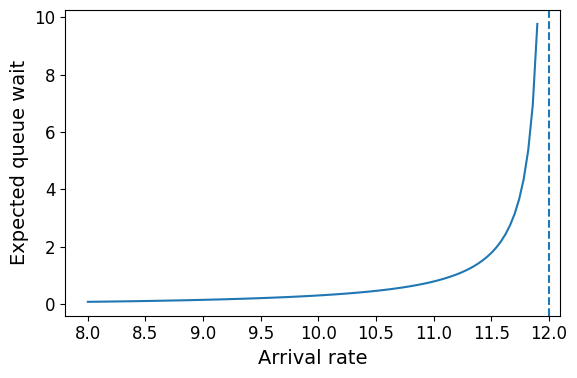

In [83]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

c = 6
mu = 2
arrival_rates = np.linspace(8, 11.9, 100)  # avoid instability at λ = cμ

def expected_waiting_time(lam):
    
    rho = lam / (c * mu)

    sum_terms = sum((lam / mu) ** n / math.factorial(n) for n in range(c))
    last_term = (lam / mu) ** c / (math.factorial(c) * (1 - rho))

    P0 = 1 / (sum_terms + last_term)

    Pw = ((lam / mu) ** c * P0) / (math.factorial(c) * (1 - rho)) # Erlang C formula for expected waiting time in M/M/c queue

    return Pw / (c * mu - lam)


Wq_vals = [expected_waiting_time(lam) for lam in arrival_rates]

plt.figure(figsize=(6, 4))
plt.plot(arrival_rates, Wq_vals)
plt.axvline(c * mu, linestyle="--") # system capacity (λ = cμ)

plt.xlabel("Arrival rate")
plt.ylabel("Expected queue wait")

plt.tight_layout()
plt.savefig("waiting-time-v-arrival-rate.pdf", bbox_inches="tight")
plt.show()

### System Dynamics Over the Day

To understand how congestion evolves over time, we simulate multiple days and track the number of patients in the system.

Because events (arrivals and departures) occur at irregular times, each simulation produces system sizes at different time points. To allow comparison across runs, these trajectories are aligned onto a common time grid using a stepwise interpolation.

We then compute:
- the average number of patients in the system at each time point
- a variability band (10th–90th percentile) to capture day-to-day variation

This provides a clear picture of how congestion builds during peak hours and persists throughout the day.

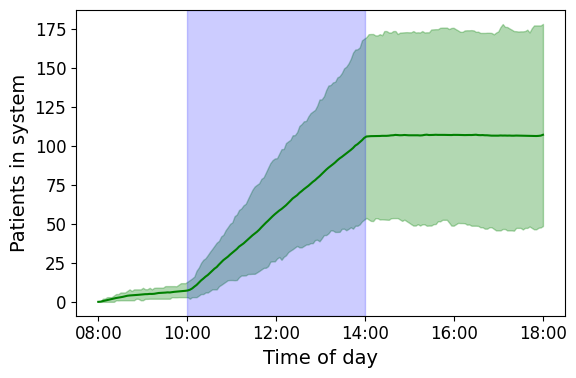

In [84]:
time_grid = np.linspace(0, 10, 200)
paths = []

for i in range(100):
    sim, _ = run_random_day()

    times = [t for t, l in sim.system_sizes]
    sizes = [l for t, l in sim.system_sizes]

    # events occur at random times, so align to a common grid for averaging
    interp = []
    j = 0
    for t in time_grid:
        while j < len(times) - 1 and times[j + 1] <= t:
            j += 1
        interp.append(sizes[j])

    paths.append(interp)

paths = np.array(paths)

mean_path = np.mean(paths, axis=0)
low_band = np.percentile(paths, 10, axis=0)
high_band = np.percentile(paths, 90, axis=0)

# Convert to real time of day (e.g. 08:00–18:00)
start_hour = 8
time_labels = start_hour + time_grid

plt.figure(figsize=(6, 4))

# Green line
plt.plot(time_labels, mean_path, color="green")

# Green shading
plt.fill_between(time_labels, low_band, high_band, color="green", alpha=0.3)

# Keep peak period blue
plt.axvspan(8 + 2, 8 + 6, color="blue", alpha=0.2)

# Format x-axis as clock time
ticks = np.arange(8, 19, 2)
labels = [f"{int(t):02d}:00" for t in ticks]
plt.xticks(ticks, labels)

plt.xlabel("Time of day")
plt.ylabel("Patients in system")

plt.tight_layout()
plt.savefig("time-of-day-sim.pdf", bbox_inches="tight")
plt.show()

### Network Model of Patient Pathway

To capture the wider healthcare pathway, we extend the model to a simple network of queues. Patients first attend the GP stage and, with a fixed probability, may then proceed to a diagnostics stage.

Arrivals follow the same time-dependent Poisson process as in the baseline model, with increased demand during peak hours. Service times at each stage are exponentially distributed, with different rates for GP consultations and diagnostics.

The system therefore consists of two interconnected service nodes:
- a GP stage with multiple clinicians
- a diagnostics stage with separate capacity

Patients are routed sequentially through the network, with a proportion requiring additional diagnostics after their GP visit. This allows us to assess how delays at the GP stage propagate to downstream services and affect overall system performance.

In [85]:
class NetworkSimulation:

    def __init__(self, lambda_rate, duration, multiplier):
        self.lambda_rate = lambda_rate
        self.duration = duration
        self.multiplier = multiplier

        self.mu_gp = 2
        self.mu_diag = 3

    def current_lambda(self, t):
        return self.lambda_rate * self.multiplier if 2 <= t < 6 else self.lambda_rate

    def interarrival(self, t):
        return np.random.exponential(1 / self.current_lambda(t))

    def service_time(self, mu):
        return np.random.exponential(1 / mu)

    def arrival_process(self, env):
        while True:
            yield env.timeout(self.interarrival(env.now))
            env.process(self.patient(env))

    def gp_stage(self, env):
        with self.gp.request() as req:
            t_arrival = env.now
            yield req
            yield env.timeout(self.service_time(self.mu_gp))
            self.gp_times.append(env.now - t_arrival) # time in GP (wait and service)

    def diagnostics_stage(self, env):
        with self.diag.request() as req:
            t_arrival = env.now
            yield req
            yield env.timeout(self.service_time(self.mu_diag))
            self.diag_times.append(env.now - t_arrival) # time in diagnostics (wait and service)

    def patient(self, env):
        yield env.process(self.gp_stage(env))
        # assuming 30% of patients require diagnostics after GP
        if np.random.rand() < 0.3:
            yield env.process(self.diagnostics_stage(env))

    def run(self):
        self.gp_times = []
        self.diag_times = []

        env = simpy.Environment()
        self.gp = simpy.Resource(env, capacity=6) # 6 GP servers
        self.diag = simpy.Resource(env, capacity=3) # 3 diagnostics servers

        env.process(self.arrival_process(env))
        env.run(until=self.duration)

        return np.mean(self.gp_times), np.mean(self.diag_times)

### Network Simulation Results

We simulate multiple independent days of operation under the network model to estimate performance at each stage of the patient pathway.

For each run, the arrival rate and peak demand multiplier are randomly sampled, and average times are recorded separately for:
- the GP stage
- the diagnostics stage

The reported values represent the average time spent at each stage, including both waiting and service. Aggregating across multiple runs provides a robust estimate of typical performance and allows comparison between stages.

This enables us to assess how delays at the GP stage compare to downstream services and to identify where congestion is most significant within the pathway.

In [ ]:
def run_random_day_network():
    lambda_rate = np.random.uniform(8, 16)
    multiplier = np.random.uniform(2, 4)

    sim = NetworkSimulation(
        lambda_rate=lambda_rate,
        duration=10,
        multiplier=multiplier
    )

    return sim, sim.run()

gp_all = []
diag_all = []

for i in range(100):
    sim, (gp_time, diag_time) = run_random_day_network()

    gp_all.append(gp_time)
    diag_all.append(diag_time)

print("Mean GP time in system:", np.mean(gp_all))
print("Mean diagnostics time in system:", np.mean(diag_all))

Mean GP time in system: 2.385566932404043
Mean diagnostics time in system: 0.3411277136286768


### Note
The addition of diagnostics does not affect the GP queue directly, as all patients must pass through the GP before any routing occurs. Therefore, GP waiting times should remain unchanged in expectation. Both results round to approximately 2.4, with the small difference arising from simulation variability and differences in the sequence of random events.

### Fast-Track Intervention Model

To reduce queueing delays, we introduce a fast-track system in which patients are separated into simple and complex cases.

Upon arrival, each patient is routed probabilistically:
- 60% of patients are classified as simple cases and assigned to a fast-track pathway
- 40% are classified as complex cases and follow the standard pathway

Simple cases are served by 2 dedicated clinicians with shorter consultation times (mean service time $1/4$ hours), while complex cases are served by 4 clinicians with longer consultation times (mean service time $1/2$ hours).

This replaces the single shared queue with two parallel service streams. By separating patients in this way, shorter consultations are no longer delayed by more complex cases, allowing capacity to be used more efficiently and reducing overall waiting times.

In [88]:
class FastTrackSimulation:

    def __init__(self, lambda_rate, duration, multiplier, p_simple=0.6):
        self.lambda_rate = lambda_rate
        self.duration = duration
        self.multiplier = multiplier
        self.p_simple = p_simple

    def current_lambda(self, t):
        return self.lambda_rate * self.multiplier if 2 <= t < 6 else self.lambda_rate

    def interarrival(self, t):
        return np.random.exponential(1 / self.current_lambda(t))

    def service_time(self, mu):
        return np.random.exponential(1 / mu)

    def system_size(self):
        return (
            len(self.simple.queue) + len(self.simple.users) +
            len(self.complex.queue) + len(self.complex.users)
        )

    def arrival_process(self, env):
        while True:
            yield env.timeout(self.interarrival(env.now))
            env.process(self.patient(env))

    def patient(self, env):
        # route patients to either the simple pathway or complex pathway
        if np.random.rand() < self.p_simple:
            yield env.process(self.simple_path(env))
        else:
            yield env.process(self.complex_path(env))

    def simple_path(self, env):
        t_arrival = env.now
        self.system_sizes.append((t_arrival, self.system_size()))

        with self.simple.request() as req:
            yield req
            t_service = env.now

            wait_time = t_service - t_arrival
            self.wait_times.append(wait_time)

            service_duration = self.service_time(4)
            self.service_times.append(service_duration)
            yield env.timeout(service_duration)

            t_depart = env.now
            self.system_sizes.append((t_depart, self.system_size() - 1))

            self.time_in_system.append(t_depart - t_arrival)

    def complex_path(self, env):
        t_arrival = env.now
        self.system_sizes.append((t_arrival, self.system_size()))

        with self.complex.request() as req:
            yield req
            t_service = env.now

            wait_time = t_service - t_arrival
            self.wait_times.append(wait_time)

            service_duration = self.service_time(2)
            self.service_times.append(service_duration)
            yield env.timeout(service_duration)

            t_depart = env.now
            self.system_sizes.append((t_depart, self.system_size() - 1))

            self.time_in_system.append(t_depart - t_arrival)

    def run(self):
        self.wait_times = []
        self.time_in_system = []
        self.service_times = []
        self.system_sizes = [(0, 0)]

        env = simpy.Environment()
        self.simple = simpy.Resource(env, capacity=2) # fast track simple cases 
        self.complex = simpy.Resource(env, capacity=4) # complex cases
        env.process(self.arrival_process(env))
        env.run(until=self.duration)

        self.system_sizes.append((self.duration, self.system_size()))

        avg_service = np.mean(self.service_times) if self.service_times else 0
        avg_wait = np.mean(self.wait_times) if self.wait_times else 0
        avg_time = np.mean(self.time_in_system)

        auc, last_t, last_l = 0, 0, 0
        for t, l in self.system_sizes:
            auc += (t - last_t) * last_l
            last_t, last_l = t, l

        avg_L = auc / last_t

        return avg_service, avg_wait, avg_time, avg_L

In [ ]:
def run_random_day_fasttrack():
    lambda_rate = np.random.uniform(8, 16)
    multiplier = np.random.uniform(2, 4)

    sim = FastTrackSimulation(
        lambda_rate=lambda_rate,
        duration=10,
        multiplier=multiplier
    )

    return sim, sim.run()

runs = 100

services_all_ft = []
wait_times_all_ft = []
time_in_system_all_ft = []
system_means_ft = []
max_system_ft = []
backlogs_ft = []

for i in range(runs):
    sim, (avg_service, avg_wait, avg_time, avg_L) = run_random_day_fasttrack()

    services_all_ft.append(avg_service)
    system_means_ft.append(avg_L)

    wait_times_all_ft.extend(sim.wait_times)
    time_in_system_all_ft.extend(sim.time_in_system)

    sizes = [l for t, l in sim.system_sizes]
    max_system_ft.append(max(sizes))
    backlogs_ft.append(sizes[-1])

wait_times_all_ft = np.array(wait_times_all_ft)
time_in_system_all_ft = np.array(time_in_system_all_ft)
print("Fast-track results:")

print("Mean service time (fast-track):", np.mean(services_all_ft))
print("Mean queue wait (fast-track):", np.mean(wait_times_all_ft))
print("Mean time in system (fast-track):", np.mean(time_in_system_all_ft))
print("90th percentile time in system (fast-track):", np.percentile(time_in_system_all_ft, 90))
print("Mean number in system (fast-track):", np.mean(system_means_ft))
print("Average max system size (fast-track):", np.mean(max_system_ft))
print("Average backlog (fast-track):", np.mean(backlogs_ft))
print("Proportion >1hr (fast-track):", np.mean(time_in_system_all_ft > 1))

Fast-track results:
Mean service time (fast-track): 0.3788007815906629
Mean queue wait (fast-track): 1.6853241197419602
Mean time in system (fast-track): 1.9800584619091905
90th percentile time in system (fast-track): 4.137593397557309
Mean number in system (fast-track): 49.375594900958184
Average max system size (fast-track): 87.31
Average backlog (fast-track): 71.16
Proportion >1hr (fast-track): 0.6718409981140288


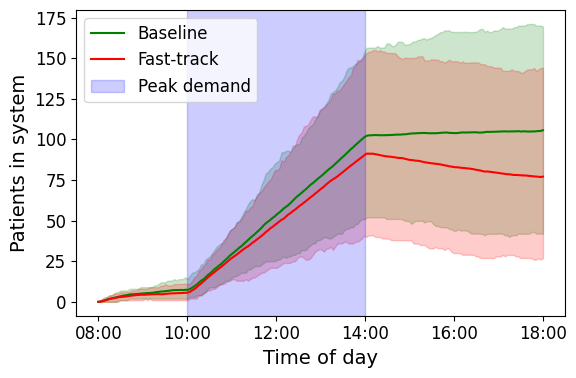

In [91]:
time_grid = np.linspace(0, 10, 200)


paths = []
for i in range(100):
    sim, _ = run_random_day()

    times = [t for t, l in sim.system_sizes]
    sizes = [l for t, l in sim.system_sizes]

    # align irregular event times onto a common grid
    interp = []
    j = 0
    for t in time_grid:
        while j < len(times) - 1 and times[j + 1] <= t:
            j += 1
        interp.append(sizes[j])

    paths.append(interp)

paths = np.array(paths)
mean_path = np.mean(paths, axis=0)
low_band = np.percentile(paths, 10, axis=0)
high_band = np.percentile(paths, 90, axis=0)


paths_ft = []
for i in range(100):
    sim, _ = run_random_day_fasttrack()

    times = [t for t, l in sim.system_sizes]
    sizes = [l for t, l in sim.system_sizes]

    interp = []
    j = 0
    for t in time_grid:
        while j < len(times) - 1 and times[j + 1] <= t:
            j += 1
        interp.append(sizes[j])

    paths_ft.append(interp)

paths_ft = np.array(paths_ft)
mean_path_ft = np.mean(paths_ft, axis=0)
low_band_ft = np.percentile(paths_ft, 10, axis=0)
high_band_ft = np.percentile(paths_ft, 90, axis=0)

start_hour = 8
time_labels = start_hour + time_grid

plt.figure(figsize=(6, 4))

# Lines
plt.plot(time_labels, mean_path, label="Baseline", color="green")
plt.plot(time_labels, mean_path_ft, label="Fast-track", color="red")

# Shaded bands
plt.fill_between(time_labels, low_band, high_band, color="green", alpha=0.2)
plt.fill_between(time_labels, low_band_ft, high_band_ft, color="red", alpha=0.2)

# Peak demand (blue)
plt.axvspan(8 + 2, 8 + 6, color="blue", alpha=0.2, label="Peak demand")

# Time formatting
ticks = np.arange(8, 19, 2)
labels = [f"{int(t):02d}:00" for t in ticks]
plt.xticks(ticks, labels)

plt.xlabel("Time of day")
plt.ylabel("Patients in system")

plt.legend()
plt.tight_layout()
plt.savefig("baseline-vs-fasttrack.pdf", bbox_inches="tight")
plt.show()